In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Connect to SQLite database
conn = sqlite3.connect("../data/processed/retail_analysis.db")

In [2]:
# 1. Monthly revenue trend
monthly_sales_query = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS sales_month,
    SUM(Revenue) AS monthly_revenue,
    COUNT(*) AS order_lines
FROM fact_sales
GROUP BY sales_month
ORDER BY sales_month;
"""

df_monthly = pd.read_sql(monthly_sales_query, conn)
df_monthly.head()

,sales_month,monthly_revenue,order_lines
0,2009-12,686654.160,30754
1,2010-01,557319.062,21775
2,2010-02,506371.066,23367
3,2010-03,699608.991,32301
4,2010-04,594609.192,27235


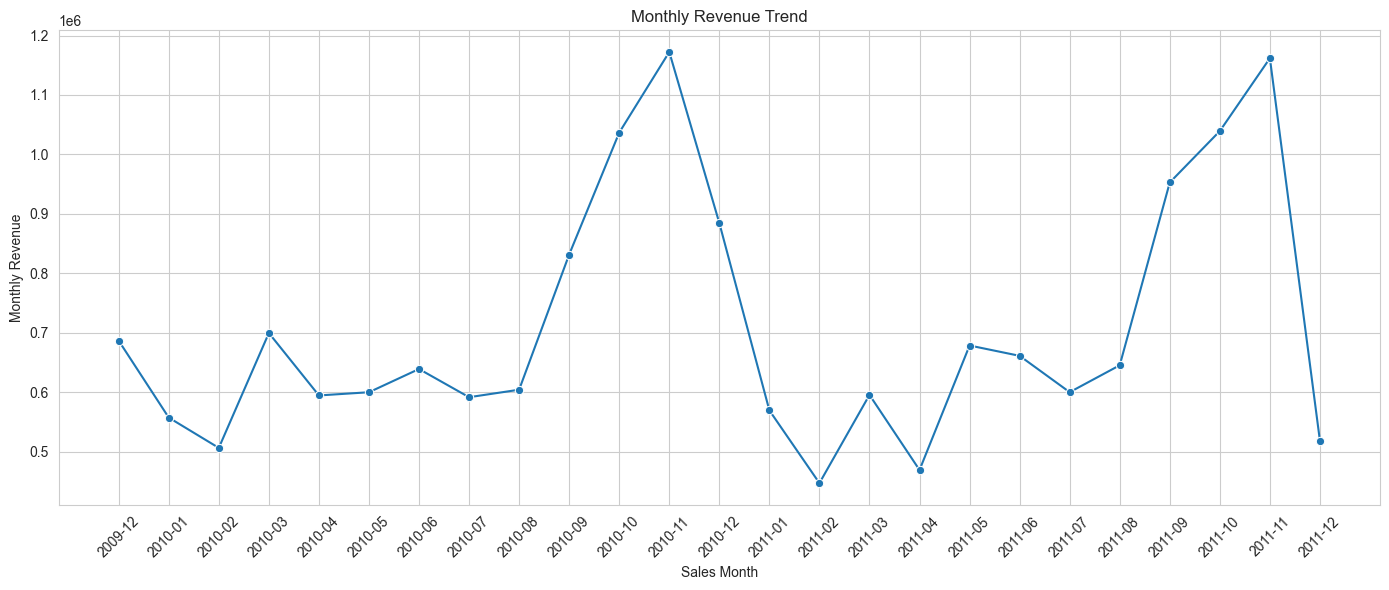

In [3]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df_monthly, x="sales_month", y="monthly_revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Sales Month")
plt.ylabel("Monthly Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# 2. Top 10 products by revenue
top_products_query = """
SELECT 
    Description,
    SUM(Revenue) AS total_revenue
FROM fact_sales
GROUP BY Description
ORDER BY total_revenue DESC
LIMIT 10;
"""

df_top_products = pd.read_sql(top_products_query, conn)
df_top_products.head()

,Description,total_revenue
0,REGENCY CAKESTAND 3 TIER,286486.30
1,WHITE HANGING HEART T-LIGHT HOLDER,252072.46
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,Manual,152340.57
4,JUMBO BAG RED RETROSPOT,136980.08


C:\Users\Tyush01\AppData\Local\Temp\ipykernel_8976\1447308883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_products, y="Description", x="total_revenue", palette="viridis")


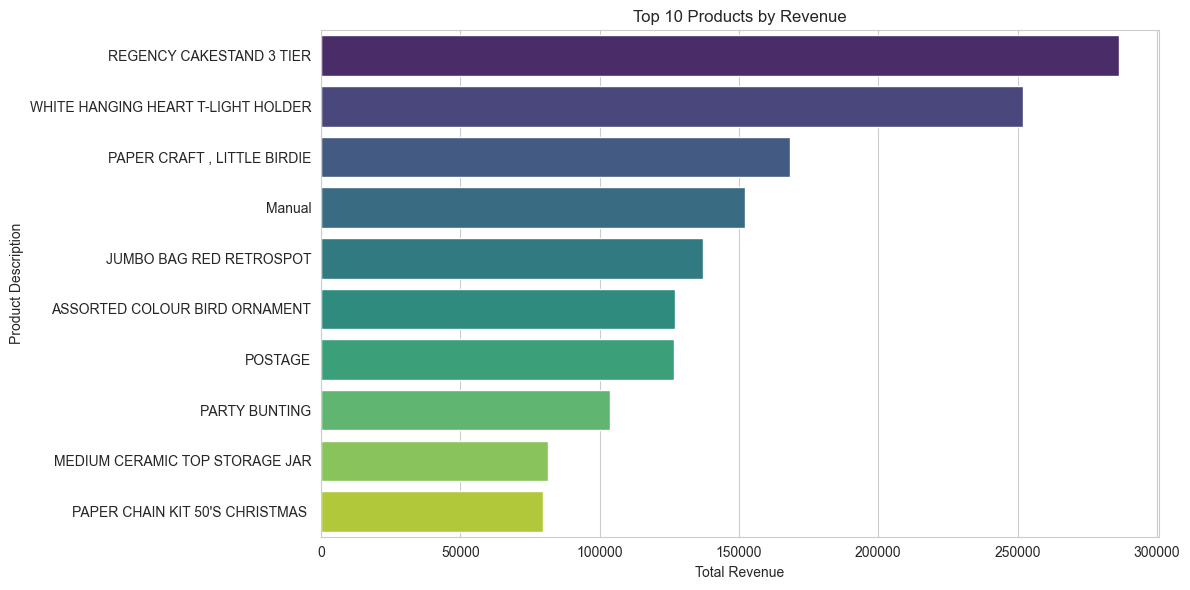

In [5]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_top_products, y="Description", x="total_revenue", palette="viridis")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Description")
plt.tight_layout()
plt.show()

In [6]:
# 3. Customer concentration
customer_concentration_query = """
WITH customer_totals AS (
    SELECT CustomerID, SUM(Revenue) AS total_spent
    FROM fact_sales
    GROUP BY CustomerID
),
threshold AS (
    SELECT AVG(total_spent) AS avg_spent
    FROM customer_totals
)
SELECT
    CASE
        WHEN total_spent > (SELECT avg_spent FROM threshold) THEN 'Above Average Spenders'
        ELSE 'Below Average Spenders'
    END AS customer_group,
    COUNT(*) AS customers,
    ROUND(SUM(total_spent), 2) AS revenue
FROM customer_totals
GROUP BY customer_group
ORDER BY revenue DESC;
"""

df_customer_concentration = pd.read_sql(customer_concentration_query, conn)
df_customer_concentration

,customer_group,customers,revenue
0,Above Average Spenders,1151,13633584.23
1,Below Average Spenders,4727,4109844.95


C:\Users\Tyush01\AppData\Local\Temp\ipykernel_8976\1642893931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_customer_concentration, x="customer_group", y="revenue", palette="magma")


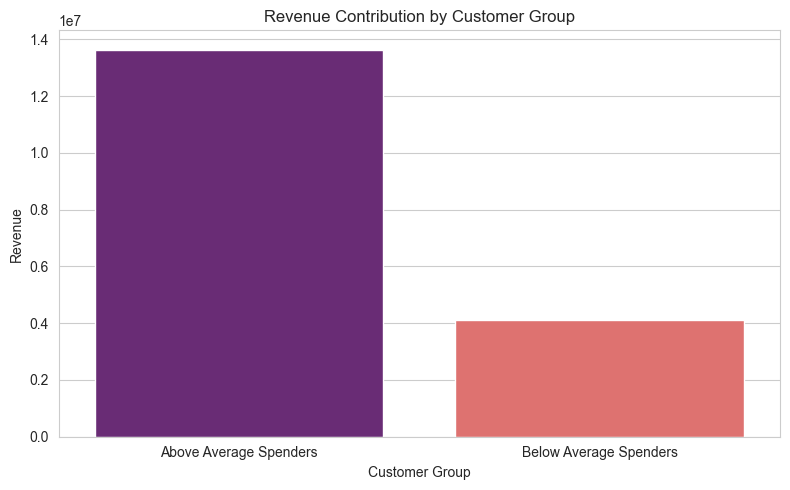

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_customer_concentration, x="customer_group", y="revenue", palette="magma")
plt.title("Revenue Contribution by Customer Group")
plt.xlabel("Customer Group")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [8]:
# 4. Revenue by country
country_revenue_query = """
SELECT 
    Country,
    SUM(Revenue) AS total_revenue,
    COUNT(DISTINCT CustomerID) AS customers
FROM fact_sales
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10;
"""

df_country_revenue = pd.read_sql(country_revenue_query, conn)
df_country_revenue.head()

,Country,total_revenue,customers
0,United Kingdom,1.472315e+07,5350
1,EIRE,6.216311e+05,5
2,Netherlands,5.542323e+05,22
3,Germany,4.312625e+05,107
4,France,3.552575e+05,95


C:\Users\Tyush01\AppData\Local\Temp\ipykernel_8976\177214660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_country_revenue, y="Country", x="total_revenue", palette="crest")


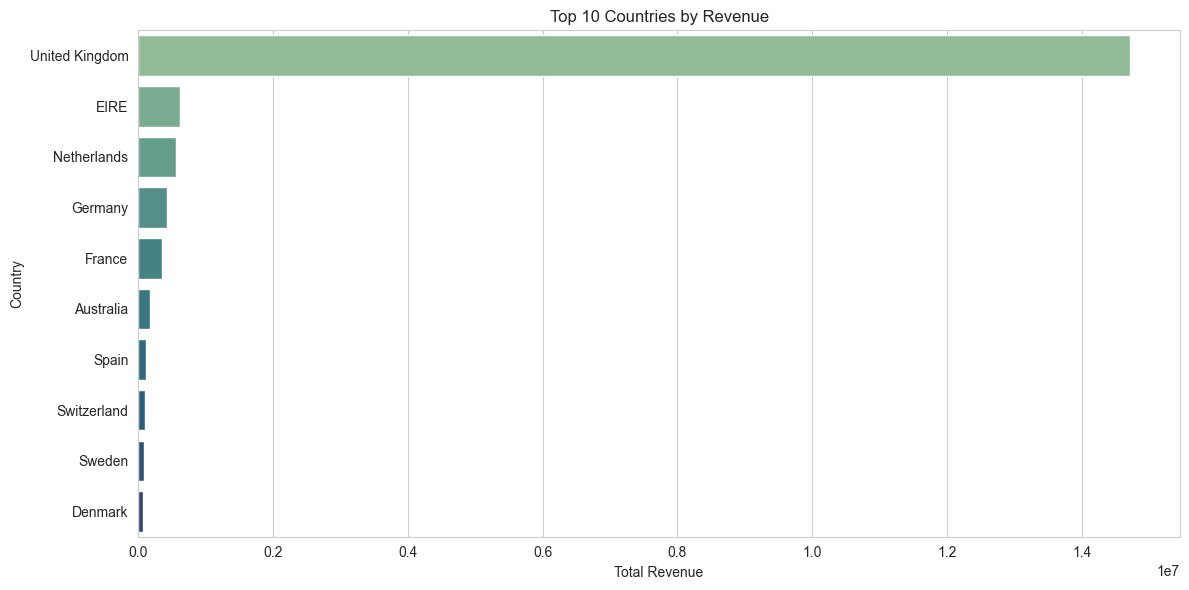

In [9]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_country_revenue, y="Country", x="total_revenue", palette="crest")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [10]:
# 5. Average customer monthly revenue
monthly_avg_customer_query = """
WITH monthly_customer AS (
    SELECT 
        strftime('%Y-%m', InvoiceDate) AS sales_month,
        CustomerID,
        SUM(Revenue) AS customer_month_revenue
    FROM fact_sales
    GROUP BY sales_month, CustomerID
)
SELECT
    sales_month,
    ROUND(AVG(customer_month_revenue), 2) AS avg_customer_month_revenue
FROM monthly_customer
GROUP BY sales_month
ORDER BY sales_month;
"""

df_monthly_avg_customer = pd.read_sql(monthly_avg_customer_query, conn)
df_monthly_avg_customer.head()

,sales_month,avg_customer_month_revenue
0,2009-12,719.01
1,2010-01,774.05
2,2010-02,655.92
3,2010-03,661.88
4,2010-04,631.22


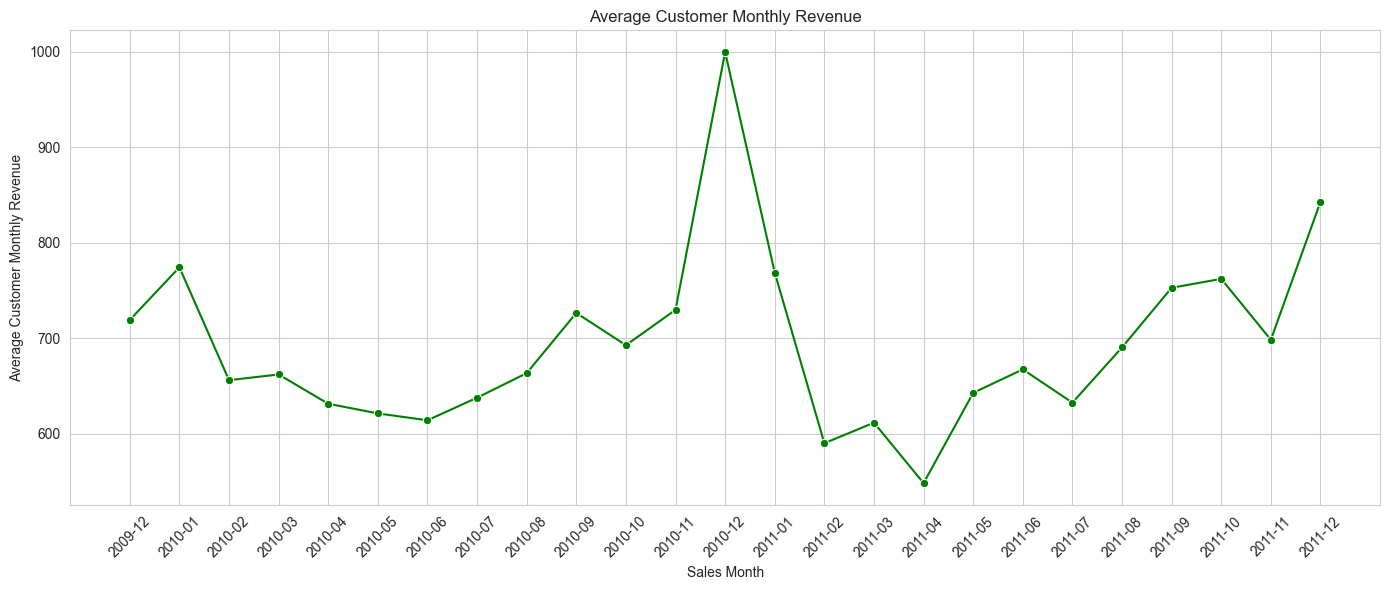

In [11]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df_monthly_avg_customer, x="sales_month", y="avg_customer_month_revenue", marker="o", color="green")
plt.title("Average Customer Monthly Revenue")
plt.xlabel("Sales Month")
plt.ylabel("Average Customer Monthly Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
customer_ltv_query = """
WITH customer_ltv AS (
    SELECT 
        CustomerID,
        COUNT(DISTINCT Invoice) AS num_orders,
        AVG(Revenue) AS avg_order_value,
        SUM(Revenue) AS total_ltv,
        MIN(InvoiceDate) AS first_order,
        MAX(InvoiceDate) AS last_order,
        julianday(MAX(InvoiceDate)) - julianday(MIN(InvoiceDate)) AS customer_tenure_days
    FROM fact_sales
    GROUP BY CustomerID
)
SELECT 
    CASE 
        WHEN num_orders >= 5 AND total_ltv > 5000 THEN 'VIP'
        WHEN total_ltv > 2000 THEN 'Loyal'
        WHEN num_orders >= 2 THEN 'Repeat'
        ELSE 'One-time'
    END AS customer_segment,
    COUNT(*) AS customers,
    ROUND(AVG(total_ltv), 2) AS avg_clv,
    ROUND(SUM(total_ltv), 2) AS segment_revenue
FROM customer_ltv
GROUP BY customer_segment
ORDER BY avg_clv DESC;
"""

df_customer_segments = pd.read_sql(customer_ltv_query, conn)
df_customer_segments

,customer_segment,customers,avg_clv,segment_revenue
0,VIP,647,17528.04,11340641.42
1,Loyal,1008,3508.11,3536179.04
2,Repeat,2616,906.62,2371727.44
3,One-time,1607,307.95,494881.28


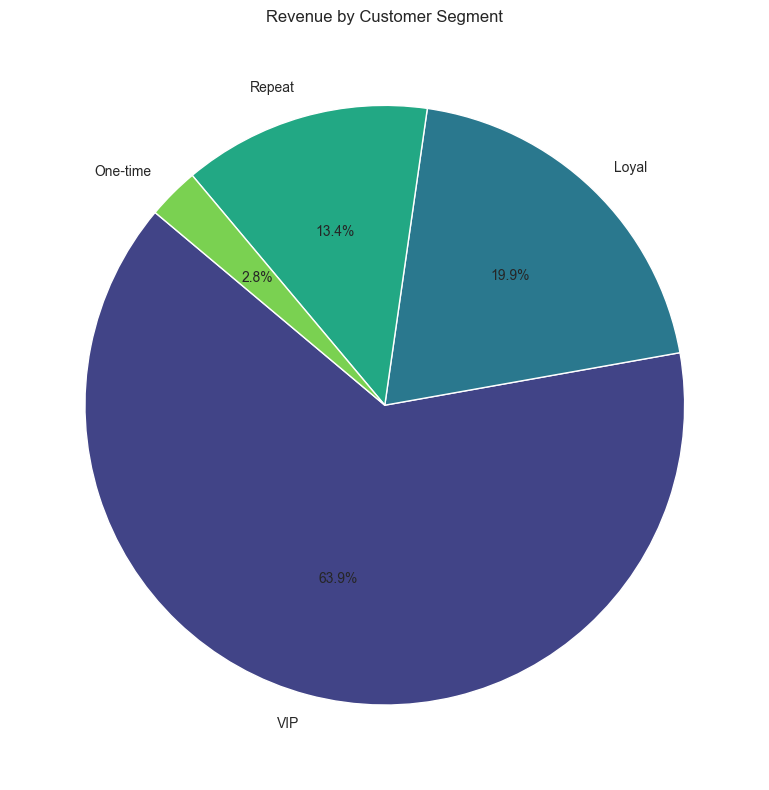

In [14]:
plt.figure(figsize=(8, 8))

plt.pie(
    df_customer_segments["segment_revenue"],
    labels=df_customer_segments["customer_segment"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("viridis", len(df_customer_segments))
)

plt.title("Revenue by Customer Segment")
plt.tight_layout()
plt.show()

In [15]:
product_affinity_query = """
WITH invoice_items AS (
    SELECT DISTINCT Invoice, StockCode, Description
    FROM fact_sales
),
pairs AS (
    SELECT 
        i1.Description AS product_1,
        i2.Description AS product_2,
        COUNT(*) AS co_occurrences
    FROM invoice_items i1
    JOIN invoice_items i2 
        ON i1.Invoice = i2.Invoice
       AND i1.StockCode < i2.StockCode
    GROUP BY i1.Description, i2.Description
    HAVING COUNT(*) > 10
)
SELECT *
FROM pairs
ORDER BY co_occurrences DESC
LIMIT 10;
"""

df_product_affinity = pd.read_sql(product_affinity_query, conn)
df_product_affinity

,product_1,product_2,co_occurrences
0,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,1153
1,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,993
2,HEART OF WICKER SMALL,HEART OF WICKER LARGE,869
3,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX,817
4,HOME BUILDING BLOCK WORD,LOVE BUILDING BLOCK WORD,786
5,LUNCH BAG BLACK SKULL.,LUNCH BAG SPACEBOY DESIGN,774
6,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,743
7,LUNCH BAG BLACK SKULL.,LUNCH BAG CARS BLUE,741
8,PACK OF 60 PINK PAISLEY CAKE CASES,60 TEATIME FAIRY CAKE CASES,736
9,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,733


C:\Users\Tyush01\AppData\Local\Temp\ipykernel_8976\4256658744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_product_affinity, y="product_1", x="co_occurrences", palette="magma")


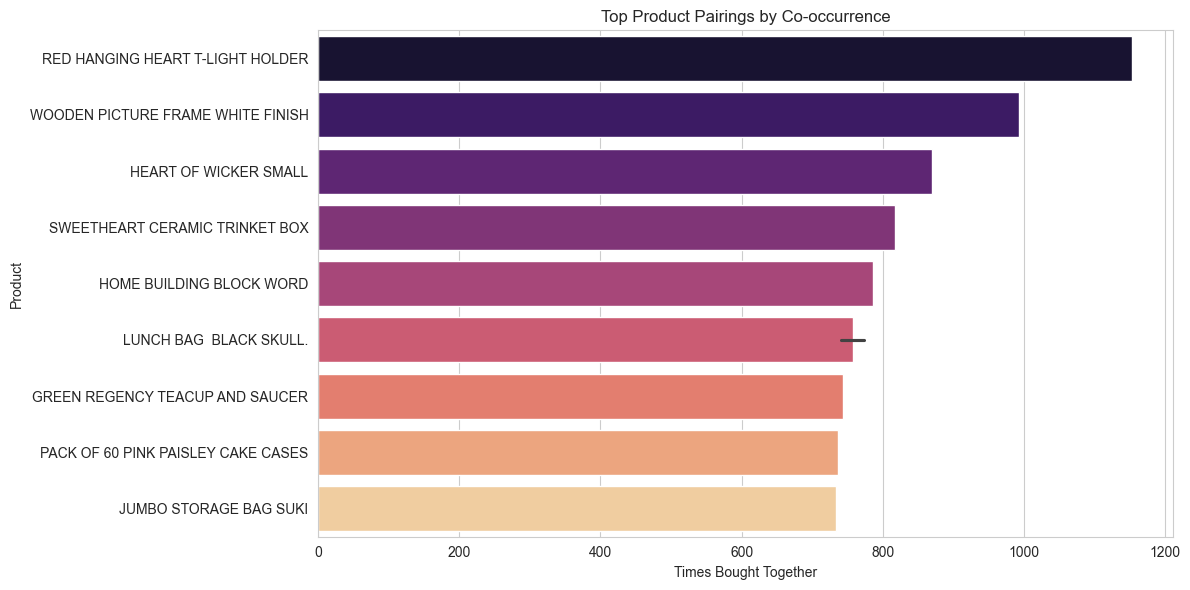

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_product_affinity, y="product_1", x="co_occurrences", palette="magma")
plt.title("Top Product Pairings by Co-occurrence")
plt.xlabel("Times Bought Together")
plt.ylabel("Product")
plt.tight_layout()
plt.show()